# Antalya Otel Cluster Bazlı Talep Tahmini

Bu notebook Antalya otellerini 2025 günlük inhouse profillerine göre kümeler, her kümede altı aday modeli recursive validation ile karşılaştırır ve 2026 Ocak-Temmuz dönemini değerlendirir.

**Tanım:** Her benzersiz rezervasyon, check-in dahil ve check-out hariç her konaklama gününde `1 occupied_night` üretir. `voucher_created_date` hiçbir aşamada kullanılmaz.

In [9]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    davies_bouldin_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TRAIN_START = pd.Timestamp("2022-01-01")
TRAIN_END = pd.Timestamp("2025-12-31")
TEST_START = pd.Timestamp("2026-01-01")
TEST_END = pd.Timestamp("2026-07-31")
VALID_START = pd.Timestamp("2025-01-01")
VALID_END = pd.Timestamp("2025-07-31")
LAGS = [7, 14, 28, 56, 112, 224]
ROLL_WINDOWS = [7, 28, 56]
FEATURE_COLUMNS = [
    "day_of_week", "week_of_year", "month", "quarter",
    "month_sin", "month_cos", "doy_sin", "doy_cos",
    *[f"lag_{lag}" for lag in LAGS],
    *[f"rolling_mean_{window}" for window in ROLL_WINDOWS],
    "days_since_start",
]

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "complete_cleaned_data_full.csv"
OUTPUT_DIR = PROJECT_ROOT / "output1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Veri: {DATA_PATH}")
print(f"Çıktı: {OUTPUT_DIR}")
print(f"Feature sayısı: {len(FEATURE_COLUMNS)}")

Veri: c:\Users\efe.turhan\Desktop\sales_forecasting\data\complete_cleaned_data_full.csv
Çıktı: c:\Users\efe.turhan\Desktop\sales_forecasting\output1
Feature sayısı: 18


## 1. Veriyi günlük inhouse paneline dönüştürme

Kaynak dosya parça parça okunur. Yalnızca Antalya kayıtları alınır; created date okunmaz. Uzun konaklamalar check-in dahil/check-out hariç günlük satırlara açılır ve otel-gün düzeyinde toplanır.

In [2]:
USE_COLUMNS = [
    "voucher_id", "sehir_adi", "hotel_id", "hotel_name",
    "voucher_checkin_date", "voucher_checout_date",
]
HISTORY_START = TRAIN_START - pd.Timedelta(days=max(LAGS))

night_parts = []
hotel_name_parts = []
seen_vouchers = set()
source_rows = antalya_rows = valid_reservations = 0

for chunk in pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="utf-8-sig",
    usecols=USE_COLUMNS,
    chunksize=250_000,
    low_memory=False,
):
    source_rows += len(chunk)
    city_mask = chunk["sehir_adi"].astype("string").str.strip().str.casefold().eq("antalya")
    chunk = chunk.loc[city_mask].copy()
    antalya_rows += len(chunk)

    chunk = chunk.dropna(subset=["voucher_id", "hotel_id", "voucher_checkin_date", "voucher_checout_date"])
    chunk = chunk.loc[~chunk["voucher_id"].isin(seen_vouchers)].copy()
    seen_vouchers.update(chunk["voucher_id"].tolist())
    chunk["checkin"] = pd.to_datetime(chunk["voucher_checkin_date"], errors="coerce").dt.normalize()
    chunk["checkout"] = pd.to_datetime(chunk["voucher_checout_date"], errors="coerce").dt.normalize()
    chunk = chunk.loc[
        chunk["checkin"].notna()
        & chunk["checkout"].notna()
        & chunk["checkout"].gt(chunk["checkin"])
        & chunk["checkin"].le(TEST_END)
        & chunk["checkout"].gt(HISTORY_START)
    ].copy()
    if chunk.empty:
        continue

    chunk["stay_start"] = chunk["checkin"].clip(lower=HISTORY_START)
    chunk["stay_end"] = chunk["checkout"].clip(upper=TEST_END + pd.Timedelta(days=1))
    chunk["nights"] = (chunk["stay_end"] - chunk["stay_start"]).dt.days.astype(int)
    chunk = chunk.loc[chunk["nights"].gt(0)]
    valid_reservations += len(chunk)
    hotel_name_parts.append(chunk[["hotel_id", "hotel_name"]])

    repeated = chunk.loc[chunk.index.repeat(chunk["nights"]), ["hotel_id", "stay_start"]].copy()
    repeated["offset"] = repeated.groupby(level=0).cumcount()
    repeated["date"] = repeated["stay_start"] + pd.to_timedelta(repeated["offset"], unit="D")
    night_parts.append(
        repeated.groupby(["hotel_id", "date"], as_index=False).size().rename(columns={"size": "occupied_nights"})
    )

inhouse_observed = (
    pd.concat(night_parts, ignore_index=True)
    .groupby(["hotel_id", "date"], as_index=False)["occupied_nights"].sum()
)
hotel_lookup = (
    pd.concat(hotel_name_parts, ignore_index=True)
    .dropna(subset=["hotel_name"])
    .groupby("hotel_id")["hotel_name"]
    .agg(lambda values: values.mode().iat[0] if not values.mode().empty else values.iloc[0])
    .rename("hotel_name")
)

hotel_ids = pd.Index(sorted(inhouse_observed["hotel_id"].unique()), name="hotel_id")
all_dates = pd.date_range(HISTORY_START, TEST_END, freq="D", name="date")
daily = (
    inhouse_observed.set_index(["hotel_id", "date"])
    .reindex(pd.MultiIndex.from_product([hotel_ids, all_dates], names=["hotel_id", "date"]), fill_value=0)
    .reset_index()
)
daily["occupied_nights"] = daily["occupied_nights"].astype(float)
daily["hotel_name"] = daily["hotel_id"].map(hotel_lookup).fillna(daily["hotel_id"].astype(str))
daily = daily.sort_values(["hotel_id", "date"]).reset_index(drop=True)

print({
    "source_rows": source_rows,
    "antalya_rows": antalya_rows,
    "valid_unique_reservations": valid_reservations,
    "hotel_count": daily["hotel_id"].nunique(),
    "panel_rows": len(daily),
    "date_min": str(daily["date"].min().date()),
    "date_max": str(daily["date"].max().date()),
})
display(daily.head())

{'source_rows': 343060, 'antalya_rows': 145239, 'valid_unique_reservations': 135707, 'hotel_count': 867, 'panel_rows': 1644699, 'date_min': '2021-05-22', 'date_max': '2026-07-31'}


,hotel_id,date,occupied_nights,hotel_name
0,371,2021-05-22,2.0,Ela Excellence Resort Belek
1,371,2021-05-23,2.0,Ela Excellence Resort Belek
2,371,2021-05-24,0.0,Ela Excellence Resort Belek
3,371,2021-05-25,1.0,Ela Excellence Resort Belek
4,371,2021-05-26,2.0,Ela Excellence Resort Belek


## 2. Otel clustering

Cluster girdisi 2025 yılındaki 365 günlük eğrinin otel yıllık toplamına bölünmüş hali ile yapısal özetlerden oluşur. `k=2..8` için silhouette, Davies-Bouldin ve inertia hesaplanır. Otomatik seçim; yüksek silhouette, düşük Davies-Bouldin ve inertia dirseğine yakınlığı birlikte puanlar.

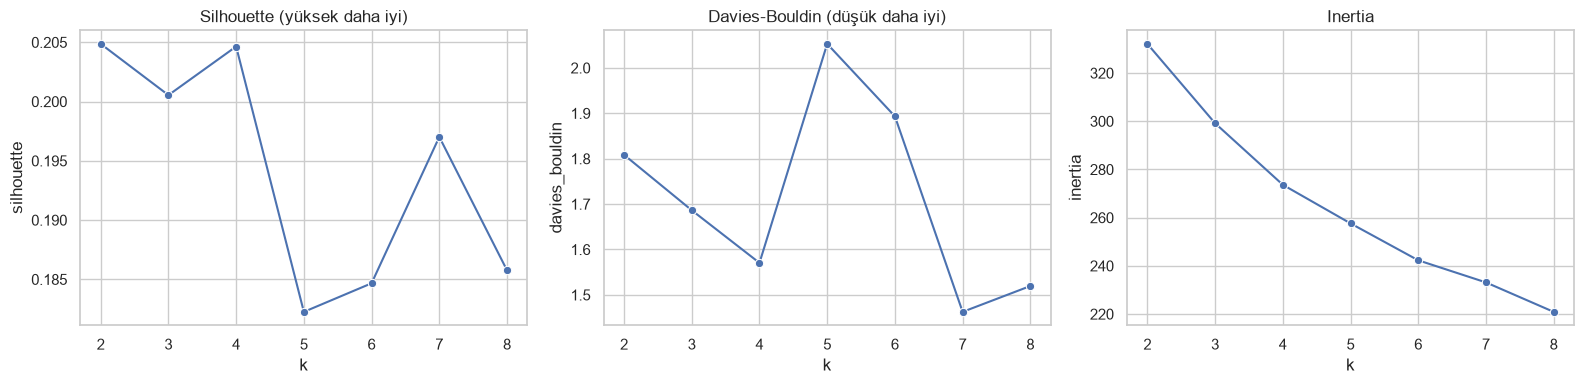

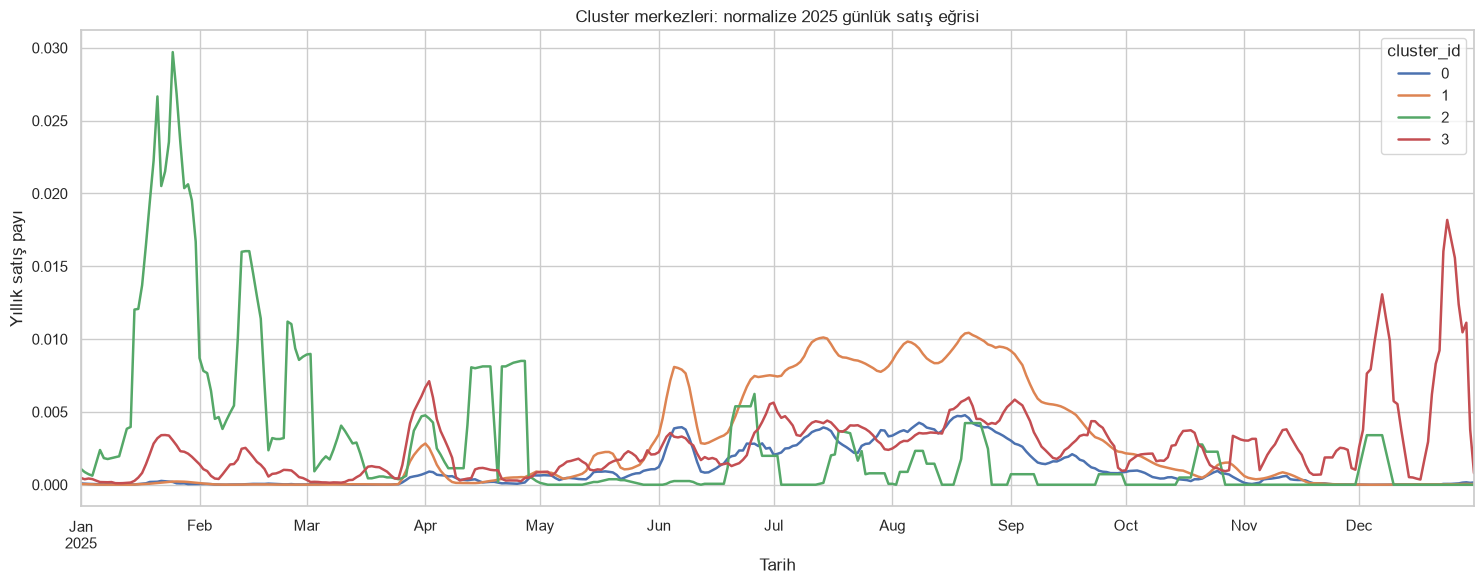

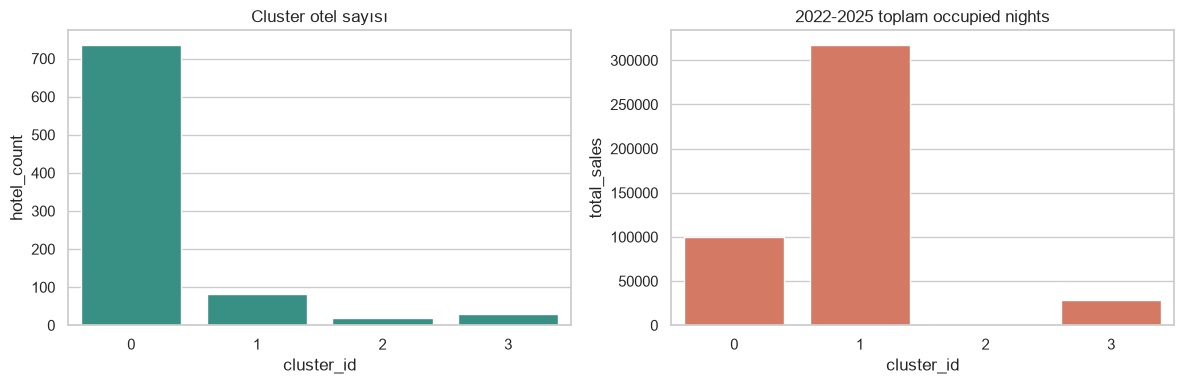

Merkez öğreniminde kullanılan otel: 205 / 867
Optimum cluster sayısı: 4


,k,silhouette,davies_bouldin,inertia,elbow_strength,selection_score
0,2,0.2049,1.8085,332.1122,0.0000,1.4140
1,3,0.2005,1.6864,299.1740,0.1295,2.1026
2,4,0.2046,1.5705,273.6392,0.1924,2.8074
3,5,0.1823,2.0529,257.6154,0.1698,0.8826
4,6,0.1847,1.8933,242.2959,0.1409,1.1094
5,7,0.1970,1.4626,233.1218,0.0567,1.9477
6,8,0.1858,1.5195,220.8963,0.0000,1.0586


,cluster_id,hotel_count,center_fit_hotel_count,total_sales,average_daily_sales,average_season_length,annual_total_2025,peak_intensity,coefficient_of_variation,summer_winter_ratio
0,0,737,102,99564.0,0.092,0.970,10723.0,0.253,2.756,10.413
1,1,82,82,317889.0,2.653,4.329,110126.0,0.332,1.746,736.967
2,2,18,2,1270.0,0.048,2.278,301.0,0.669,10.073,0.522
3,3,30,19,28475.0,0.650,5.100,9445.0,0.418,4.840,9.957


,cluster_id,annual_total_2025,peak_month,peak_intensity,coefficient_of_variation,season_length,summer_winter_ratio
0,0,14.550,2.944,0.253,2.756,0.970,10.413
1,1,1343.000,7.598,0.332,1.746,4.329,736.967
2,2,16.722,1.667,0.669,10.073,2.278,0.522
3,3,314.833,8.600,0.418,4.840,5.100,9.957


In [4]:
cluster_2025 = daily.loc[daily["date"].dt.year.eq(2025), ["hotel_id", "date", "occupied_nights"]].copy()
cluster_2025["month"] = cluster_2025["date"].dt.month

curve = (
    cluster_2025.pivot(index="hotel_id", columns="date", values="occupied_nights")
    .reindex(index=hotel_ids, fill_value=0)
    .fillna(0)
)
curve.columns = [f"day_{date:%m%d}" for date in curve.columns]
yearly_total = curve.sum(axis=1)
normalized_curve = curve.div(yearly_total.replace(0, np.nan), axis=0).fillna(0)
normalized_curve = normalized_curve.T.rolling(7, center=True, min_periods=1).mean().T
normalized_curve = normalized_curve.div(normalized_curve.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

monthly_2025 = cluster_2025.groupby(["hotel_id", "month"])["occupied_nights"].sum().unstack(fill_value=0).reindex(index=hotel_ids, columns=range(1, 13), fill_value=0)
peak_month = monthly_2025.idxmax(axis=1).where(yearly_total.gt(0), 0)
peak_value = monthly_2025.max(axis=1)
structural_features = pd.DataFrame(index=hotel_ids)
structural_features["annual_total_2025"] = yearly_total
structural_features["peak_month"] = peak_month
structural_features["peak_intensity"] = peak_value.div(yearly_total.replace(0, np.nan)).fillna(0)
structural_features["coefficient_of_variation"] = curve.std(axis=1).div(curve.mean(axis=1).replace(0, np.nan)).fillna(0)
structural_features["season_length"] = monthly_2025.ge(peak_value.mul(0.20), axis=0).sum(axis=1).where(peak_value.gt(0), 0)
structural_features["summer_winter_ratio"] = monthly_2025[[6, 7, 8]].sum(axis=1).add(1).div(monthly_2025[[12, 1, 2]].sum(axis=1).add(1))

# Çok seyrek profiller merkez öğrenimini bozmasın; yine de bütün oteller sonradan en yakın merkeze atanır.
MIN_CLUSTER_SIGNAL = 30
fit_mask = yearly_total.ge(MIN_CLUSTER_SIGNAL)
model_structural = structural_features.copy()
model_structural["annual_total_2025"] = np.log1p(model_structural["annual_total_2025"])
model_structural["summer_winter_ratio"] = np.log1p(model_structural["summer_winter_ratio"])
for column in ["coefficient_of_variation", "peak_intensity"]:
    model_structural[column] = model_structural[column].clip(upper=model_structural.loc[fit_mask, column].quantile(0.99))

curve_scaler = StandardScaler()
structural_scaler = StandardScaler()
curve_scaled = curve_scaler.fit(normalized_curve.loc[fit_mask]).transform(normalized_curve)
structural_scaled = structural_scaler.fit(model_structural.loc[fit_mask]).transform(model_structural)
cluster_matrix = np.hstack([
    curve_scaled / np.sqrt(curve_scaled.shape[1]),
    structural_scaled / np.sqrt(structural_scaled.shape[1]),
])
fit_matrix = cluster_matrix[fit_mask.to_numpy()]

cluster_diagnostics = []
models_by_k = {}
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    fit_labels = kmeans.fit_predict(fit_matrix)
    models_by_k[k] = kmeans
    cluster_diagnostics.append({
        "k": k,
        "silhouette": silhouette_score(fit_matrix, fit_labels),
        "davies_bouldin": davies_bouldin_score(fit_matrix, fit_labels),
        "inertia": kmeans.inertia_,
    })

cluster_diagnostics = pd.DataFrame(cluster_diagnostics)
def minmax(series):
    span = series.max() - series.min()
    return (series - series.min()) / span if span else pd.Series(0.0, index=series.index)

inertia_norm = minmax(cluster_diagnostics["inertia"])
line_y = np.linspace(inertia_norm.iloc[0], inertia_norm.iloc[-1], len(inertia_norm))
cluster_diagnostics["elbow_strength"] = line_y - inertia_norm
cluster_diagnostics["selection_score"] = (
    minmax(cluster_diagnostics["silhouette"])
    + minmax(-cluster_diagnostics["davies_bouldin"])
    + minmax(cluster_diagnostics["elbow_strength"])
)
optimal_k = int(cluster_diagnostics.loc[cluster_diagnostics["selection_score"].idxmax(), "k"])
cluster_model = models_by_k[optimal_k]
cluster_assignments = pd.DataFrame({"hotel_id": hotel_ids, "cluster_id": cluster_model.predict(cluster_matrix)})
cluster_assignments["hotel_name"] = cluster_assignments["hotel_id"].map(hotel_lookup)
cluster_assignments["used_for_center_fit"] = cluster_assignments["hotel_id"].map(fit_mask).fillna(False)

cluster_feature_frame = pd.concat([normalized_curve, structural_features], axis=1)
cluster_centers = (
    cluster_feature_frame.reset_index()
    .merge(cluster_assignments[["hotel_id", "cluster_id"]], on="hotel_id")
    .groupby("cluster_id", as_index=False)
    .mean(numeric_only=True)
    .drop(columns="hotel_id", errors="ignore")
)
cluster_center_summary = cluster_centers[["cluster_id", *structural_features.columns]]

sales_train = daily.loc[daily["date"].between(TRAIN_START, TRAIN_END)].groupby("hotel_id")["occupied_nights"].agg(["sum", "mean"])
cluster_summary = (
    cluster_assignments
    .merge(structural_features.reset_index(), on="hotel_id")
    .merge(sales_train.reset_index(), on="hotel_id", how="left")
    .groupby("cluster_id", as_index=False)
    .agg(
        hotel_count=("hotel_id", "nunique"),
        center_fit_hotel_count=("used_for_center_fit", "sum"),
        total_sales=("sum", "sum"),
        average_daily_sales=("mean", "mean"),
        average_season_length=("season_length", "mean"),
        annual_total_2025=("annual_total_2025", "sum"),
        peak_intensity=("peak_intensity", "mean"),
        coefficient_of_variation=("coefficient_of_variation", "mean"),
        summer_winter_ratio=("summer_winter_ratio", "mean"),
    )
)

cluster_diagnostics.to_csv(OUTPUT_DIR / "cluster_diagnostics.csv", index=False, encoding="utf-8-sig")
cluster_assignments.to_csv(OUTPUT_DIR / "hotel_cluster_assignments.csv", index=False, encoding="utf-8-sig")
structural_features.reset_index().merge(cluster_assignments[["hotel_id", "cluster_id"]], on="hotel_id").to_csv(OUTPUT_DIR / "hotel_cluster_features.csv", index=False, encoding="utf-8-sig")
cluster_centers.to_csv(OUTPUT_DIR / "cluster_centers.csv", index=False, encoding="utf-8-sig")
cluster_summary.to_csv(OUTPUT_DIR / "cluster_summary.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.lineplot(data=cluster_diagnostics, x="k", y="silhouette", marker="o", ax=axes[0])
sns.lineplot(data=cluster_diagnostics, x="k", y="davies_bouldin", marker="o", ax=axes[1])
sns.lineplot(data=cluster_diagnostics, x="k", y="inertia", marker="o", ax=axes[2])
axes[0].set_title("Silhouette (yüksek daha iyi)")
axes[1].set_title("Davies-Bouldin (düşük daha iyi)")
axes[2].set_title("Inertia")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_k_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

profile_plot = normalized_curve.reset_index().merge(cluster_assignments[["hotel_id", "cluster_id"]], on="hotel_id").groupby("cluster_id").mean(numeric_only=True).drop(columns="hotel_id", errors="ignore").T
profile_plot.index = pd.to_datetime("2025" + profile_plot.index.str.replace("day_", ""), format="%Y%m%d")
fig, ax = plt.subplots(figsize=(15, 6))
profile_plot.plot(ax=ax, linewidth=1.8)
ax.set(title="Cluster merkezleri: normalize 2025 günlük satış eğrisi", xlabel="Tarih", ylabel="Yıllık satış payı")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_daily_profiles.png", dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=cluster_summary, x="cluster_id", y="hotel_count", ax=axes[0], color="#2a9d8f")
sns.barplot(data=cluster_summary, x="cluster_id", y="total_sales", ax=axes[1], color="#e76f51")
axes[0].set_title("Cluster otel sayısı")
axes[1].set_title("2022-2025 toplam occupied nights")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_size_and_sales.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Merkez öğreniminde kullanılan otel: {fit_mask.sum()} / {len(fit_mask)}")
print(f"Optimum cluster sayısı: {optimal_k}")
display(cluster_diagnostics.round(4), cluster_summary.round(3), cluster_center_summary.round(3))

## 3. Feature engineering, metrikler ve recursive tahmin

Validation dönemi 2025 Ocak-Temmuz'dur; bu seçim 2026 test penceresiyle aynı ayları karşılaştırır. Her aday model validation başlangıcından önceki hedeflerle eğitilir. Recursive fonksiyon her yeni günün tahminini sonraki lag ve rolling değerlerine geri besler.

In [5]:
def add_time_features(frame):
    result = frame.copy()
    iso = result["date"].dt.isocalendar()
    result["day_of_week"] = result["date"].dt.dayofweek.astype(int)
    result["week_of_year"] = iso.week.astype(int)
    result["month"] = result["date"].dt.month.astype(int)
    result["quarter"] = result["date"].dt.quarter.astype(int)
    result["month_sin"] = np.sin(2 * np.pi * result["month"] / 12)
    result["month_cos"] = np.cos(2 * np.pi * result["month"] / 12)
    day_of_year = result["date"].dt.dayofyear
    result["doy_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
    result["doy_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)
    result["days_since_start"] = (result["date"] - TRAIN_START).dt.days
    return result


def add_historical_features(frame):
    result = add_time_features(frame.sort_values(["hotel_id", "date"]))
    grouped = result.groupby("hotel_id", sort=False)["occupied_nights"]
    for lag in LAGS:
        result[f"lag_{lag}"] = grouped.shift(lag)
    for window in ROLL_WINDOWS:
        result[f"rolling_mean_{window}"] = grouped.transform(
            lambda values: values.shift(1).rolling(window, min_periods=window).mean()
        )
    return result


def regression_metrics(y_true, y_pred):
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    absolute_error = np.abs(actual - predicted)
    nonzero = actual != 0
    total_actual = np.abs(actual).sum()
    weights = np.abs(actual) / total_actual if total_actual else np.zeros_like(actual)
    return {
        "MAE": float(mean_absolute_error(actual, predicted)),
        "WMAE": float(np.sum(weights * absolute_error)) if total_actual else np.nan,
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "MAPE": float(np.mean(absolute_error[nonzero] / np.abs(actual[nonzero])) * 100) if nonzero.any() else np.nan,
        "WMAPE": float(absolute_error.sum() / total_actual * 100) if total_actual else np.nan,
        "R2": float(r2_score(actual, predicted)) if len(actual) > 1 and np.var(actual) > 0 else np.nan,
    }


def make_models():
    return {
        "RandomForest": RandomForestRegressor(
            n_estimators=120, min_samples_leaf=2, max_features=0.8,
            n_jobs=-1, random_state=RANDOM_STATE,
        ),
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=140, min_samples_leaf=2, max_features=0.9,
            n_jobs=-1, random_state=RANDOM_STATE,
        ),
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=120, learning_rate=0.05, max_depth=5,
            loss="huber", random_state=RANDOM_STATE,
        ),
        "XGBoost": XGBRegressor(
            n_estimators=180, learning_rate=0.05, max_depth=7,
            subsample=0.85, colsample_bytree=0.9, objective="reg:squarederror",
            n_jobs=-1, random_state=RANDOM_STATE,
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=220, learning_rate=0.05, num_leaves=31,
            subsample=0.85, colsample_bytree=0.9, verbosity=-1,
            n_jobs=-1, random_state=RANDOM_STATE,
        ),
        "CatBoost": CatBoostRegressor(
            iterations=220, learning_rate=0.05, depth=7,
            loss_function="MAE", verbose=False, random_seed=RANDOM_STATE,
            thread_count=-1,
        ),
    }


def sample_training_rows(frame, max_rows=250_000):
    if len(frame) <= max_rows:
        return frame
    positive = frame.loc[frame["occupied_nights"].gt(0)]
    zero = frame.loc[frame["occupied_nights"].eq(0)]
    positive_limit = min(len(positive), max_rows // 2)
    zero_limit = max_rows - positive_limit
    positive_sample = positive.sample(positive_limit, random_state=RANDOM_STATE) if len(positive) > positive_limit else positive
    zero_sample = zero.sample(min(len(zero), zero_limit), random_state=RANDOM_STATE)
    sampled = pd.concat([positive_sample, zero_sample])
    return sampled.sample(frac=1, random_state=RANDOM_STATE)


def recursive_forecast(model, source_daily, hotel_list, forecast_start, forecast_end):
    hotel_list = pd.Index(hotel_list)
    history = (
        source_daily.loc[
            source_daily["hotel_id"].isin(hotel_list) & source_daily["date"].lt(forecast_start),
            ["hotel_id", "date", "occupied_nights"],
        ]
        .pivot(index="date", columns="hotel_id", values="occupied_nights")
        .reindex(columns=hotel_list)
        .sort_index()
    )
    prediction_rows = []
    for current_date in pd.date_range(forecast_start, forecast_end, freq="D"):
        features = pd.DataFrame({"hotel_id": hotel_list, "date": current_date})
        features = add_time_features(features)
        for lag in LAGS:
            features[f"lag_{lag}"] = history.loc[current_date - pd.Timedelta(days=lag), hotel_list].to_numpy()
        for window in ROLL_WINDOWS:
            features[f"rolling_mean_{window}"] = history.iloc[-window:].mean(axis=0).reindex(hotel_list).to_numpy()
        predictions = np.clip(model.predict(features[FEATURE_COLUMNS]), 0, None)
        history.loc[current_date, hotel_list] = predictions
        prediction_rows.append(pd.DataFrame({
            "hotel_id": hotel_list,
            "date": current_date,
            "prediction": predictions,
        }))
    return pd.concat(prediction_rows, ignore_index=True)

model_daily = (
    daily.merge(cluster_assignments[["hotel_id", "cluster_id"]], on="hotel_id", how="left")
)
feature_daily = add_historical_features(model_daily).dropna(subset=FEATURE_COLUMNS)
print("Model feature paneli:", feature_daily.shape)
print("Feature tarih aralığı:", feature_daily["date"].min().date(), "-", feature_daily["date"].max().date())

Model feature paneli: (1450491, 23)
Feature tarih aralığı: 2022-01-01 - 2026-07-31


## 4. Cluster bazında model seçimi ve 2026 recursive test

Büyük cluster'larda model karşılaştırmasını uygulanabilir tutmak için eğitim örneklemi en fazla 250.000 satırdır; pozitif ve sıfır günler dengeli biçimde korunur. Validation ve test tahminleri ise ilgili cluster'daki tüm otel-günleri kapsar.

In [6]:
validation_rows = []
selected_models = {}
final_models = {}
test_prediction_parts = []

for cluster_id in sorted(cluster_assignments["cluster_id"].unique()):
    cluster_hotels = cluster_assignments.loc[cluster_assignments["cluster_id"].eq(cluster_id), "hotel_id"]
    validation_train = feature_daily.loc[
        feature_daily["cluster_id"].eq(cluster_id)
        & feature_daily["date"].between(TRAIN_START, VALID_START - pd.Timedelta(days=1))
    ]
    validation_train_sample = sample_training_rows(validation_train)
    validation_actual = model_daily.loc[
        model_daily["hotel_id"].isin(cluster_hotels)
        & model_daily["date"].between(VALID_START, VALID_END),
        ["hotel_id", "date", "occupied_nights"],
    ]

    print(f"Cluster {cluster_id}: {len(cluster_hotels)} otel, {len(validation_train_sample):,} validation eğitim satırı")
    candidate_models = make_models()
    for model_name, model in candidate_models.items():
        model.fit(validation_train_sample[FEATURE_COLUMNS], validation_train_sample["occupied_nights"])
        validation_prediction = recursive_forecast(
            model, model_daily, cluster_hotels, VALID_START, VALID_END
        )
        validation_eval = validation_actual.merge(validation_prediction, on=["hotel_id", "date"], how="inner")
        validation_rows.append({
            "cluster_id": cluster_id,
            "model": model_name,
            "train_rows": len(validation_train_sample),
            **regression_metrics(validation_eval["occupied_nights"], validation_eval["prediction"]),
        })
        print(f"  {model_name:<17} WMAPE={validation_rows[-1]['WMAPE']:.2f}%")

    cluster_validation = pd.DataFrame(validation_rows).query("cluster_id == @cluster_id")
    best_model_name = cluster_validation.sort_values(["WMAPE", "MAE"]).iloc[0]["model"]
    selected_models[cluster_id] = best_model_name

    final_train = feature_daily.loc[
        feature_daily["cluster_id"].eq(cluster_id)
        & feature_daily["date"].between(TRAIN_START, TRAIN_END)
    ]
    final_train_sample = sample_training_rows(final_train)
    final_model = make_models()[best_model_name]
    final_model.fit(final_train_sample[FEATURE_COLUMNS], final_train_sample["occupied_nights"])
    final_models[cluster_id] = final_model
    cluster_test_prediction = recursive_forecast(
        final_model, model_daily, cluster_hotels, TEST_START, TEST_END
    )
    cluster_test_prediction["cluster_id"] = cluster_id
    cluster_test_prediction["model"] = best_model_name
    test_prediction_parts.append(cluster_test_prediction)
    print(f"  Seçilen: {best_model_name}; final train={len(final_train_sample):,}\n")

model_validation_results = pd.DataFrame(validation_rows).sort_values(["cluster_id", "WMAPE"])
test_predictions = pd.concat(test_prediction_parts, ignore_index=True)
test_actual = model_daily.loc[
    model_daily["date"].between(TEST_START, TEST_END),
    ["hotel_id", "hotel_name", "date", "cluster_id", "occupied_nights"],
]
test_results = test_actual.merge(
    test_predictions,
    on=["hotel_id", "date", "cluster_id"],
    how="left",
    validate="one_to_one",
)
test_results["prediction"] = test_results["prediction"].clip(lower=0)

model_validation_results.to_csv(OUTPUT_DIR / "cluster_model_validation.csv", index=False, encoding="utf-8-sig")
test_results.to_csv(OUTPUT_DIR / "daily_hotel_predictions_2026.csv", index=False, encoding="utf-8-sig")

print("Seçilen modeller:", selected_models)
display(model_validation_results.round(3))

Cluster 0: 737 otel, 250,000 validation eğitim satırı
  RandomForest      WMAPE=67727.43%
  ExtraTrees        WMAPE=46232.40%
  GradientBoosting  WMAPE=106.52%
  XGBoost           WMAPE=1492.32%
  LightGBM          WMAPE=22448.58%
  CatBoost          WMAPE=127.53%
  Seçilen: GradientBoosting; final train=250,000

Cluster 1: 82 otel, 89,872 validation eğitim satırı
  RandomForest      WMAPE=481.01%
  ExtraTrees        WMAPE=308.87%
  GradientBoosting  WMAPE=89.49%
  XGBoost           WMAPE=113.59%
  LightGBM          WMAPE=139.35%
  CatBoost          WMAPE=99.73%
  Seçilen: GradientBoosting; final train=119,802

Cluster 2: 18 otel, 19,728 validation eğitim satırı
  RandomForest      WMAPE=1423.74%
  ExtraTrees        WMAPE=743.00%
  GradientBoosting  WMAPE=100.00%
  XGBoost           WMAPE=512.87%
  LightGBM          WMAPE=404.18%
  CatBoost          WMAPE=95.97%
  Seçilen: CatBoost; final train=26,298

Cluster 3: 30 otel, 32,880 validation eğitim satırı
  RandomForest      WMAPE=759.07

,cluster_id,model,train_rows,MAE,WMAE,RMSE,MAPE,WMAPE,R2
2,0,GradientBoosting,250000,0.035,2.967,0.316,99.642,106.524,-0.032
5,0,CatBoost,250000,0.042,2.850,0.329,98.898,127.526,-0.122
3,0,XGBoost,250000,0.491,7.491,5.795,319.110,1492.324,-346.929
4,0,LightGBM,250000,7.379,22.370,14.249,1699.854,22448.581,-2102.127
1,0,ExtraTrees,250000,15.197,32.010,22.509,2688.977,46232.402,-5247.255
0,0,RandomForest,250000,22.263,50.490,35.580,4022.858,67727.432,-13112.411
8,1,GradientBoosting,89872,2.772,20.490,7.627,71.736,89.486,0.067
11,1,CatBoost,89872,3.089,23.009,8.412,97.998,99.732,-0.135
9,1,XGBoost,89872,3.519,17.106,8.867,174.701,113.589,-0.261
10,1,LightGBM,89872,4.316,14.353,9.191,187.076,139.345,-0.355


## 5. Test analizleri ve görseller

Metrikler günlük otel-gün düzeyinde hesaplanır. Toplam tablolarında `Fark = Tahmin - Gerçek`, `Yüzde Hata = |Fark| / Gerçek × 100` tanımı kullanılır.

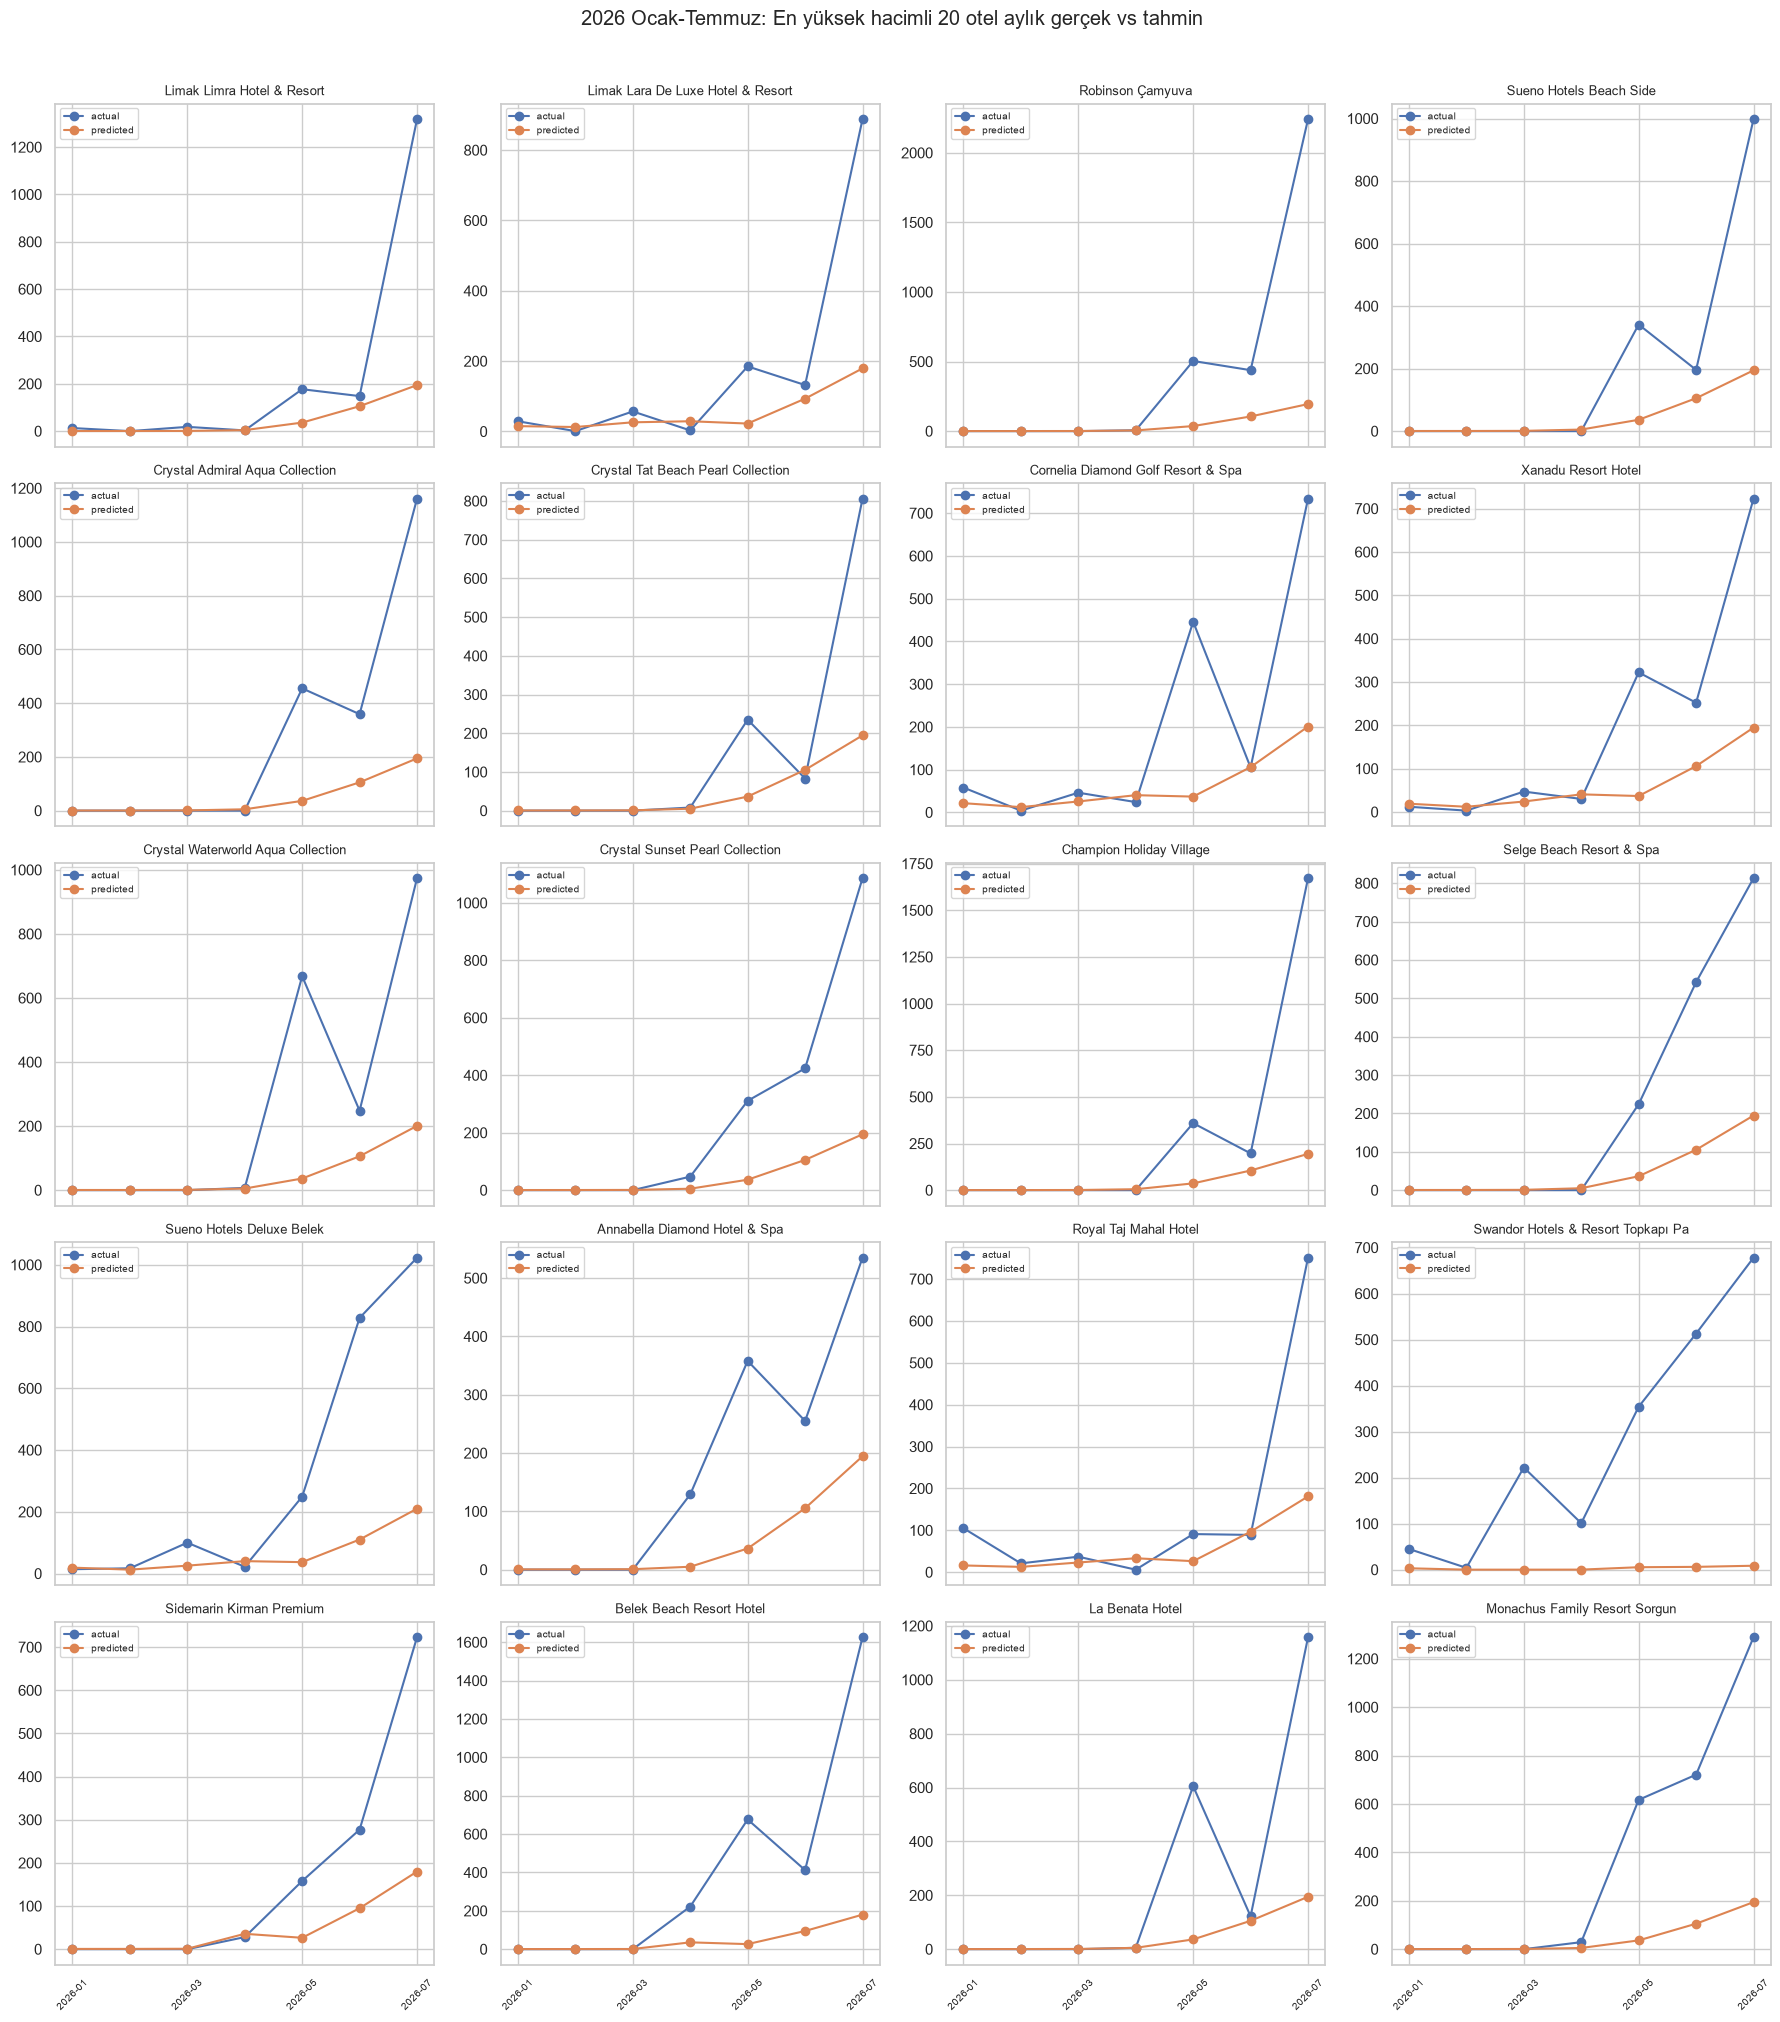

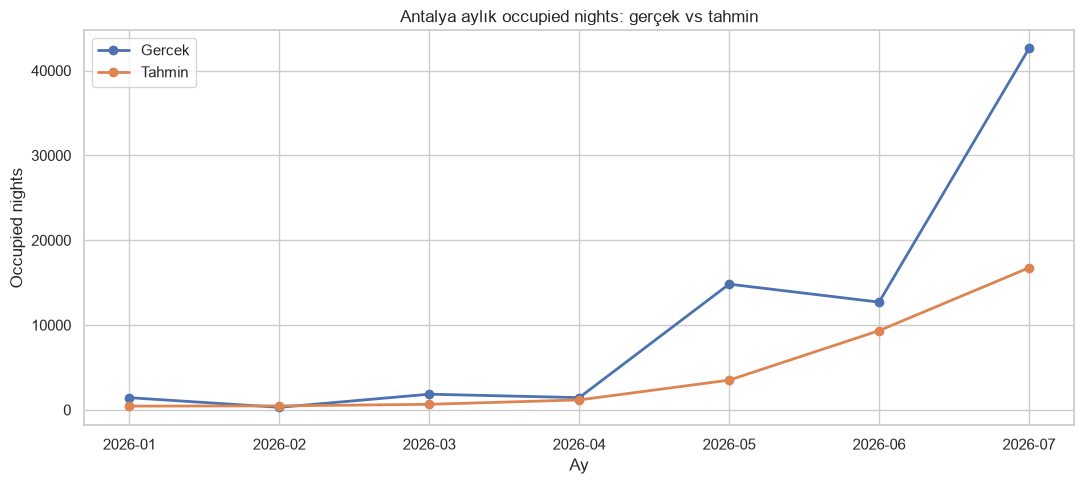

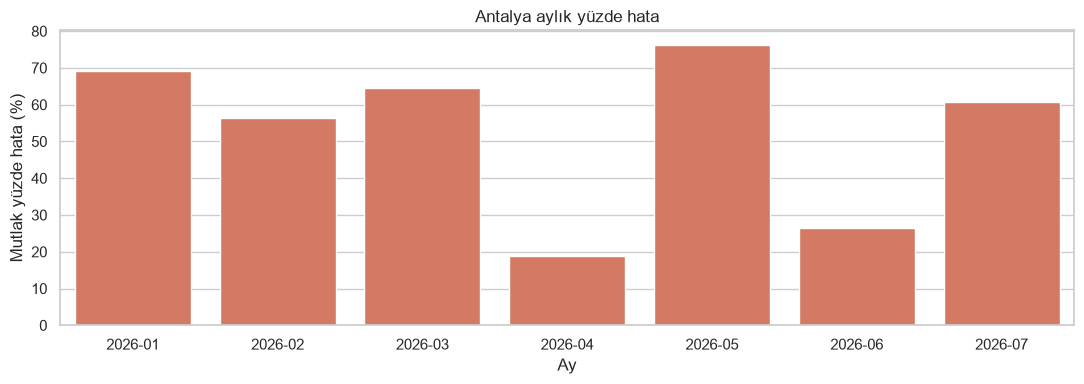

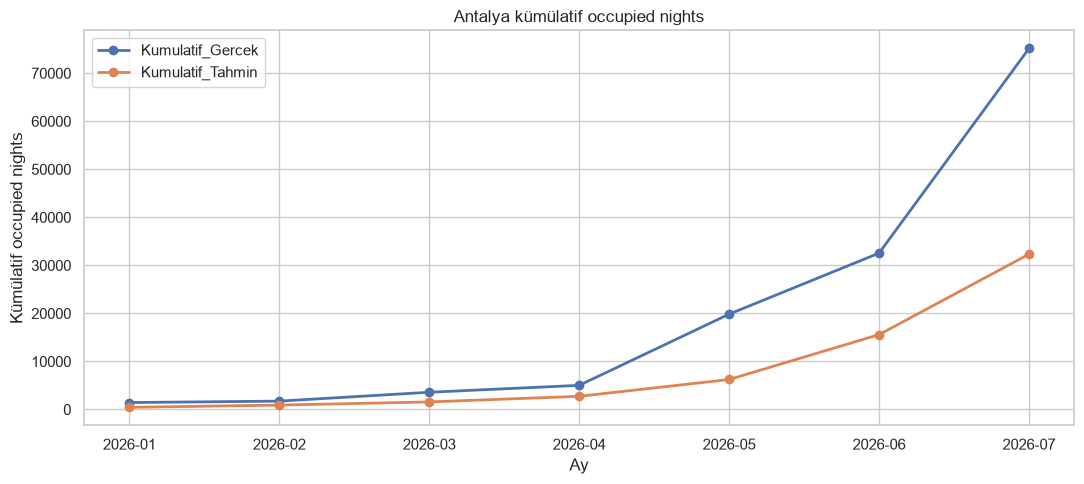

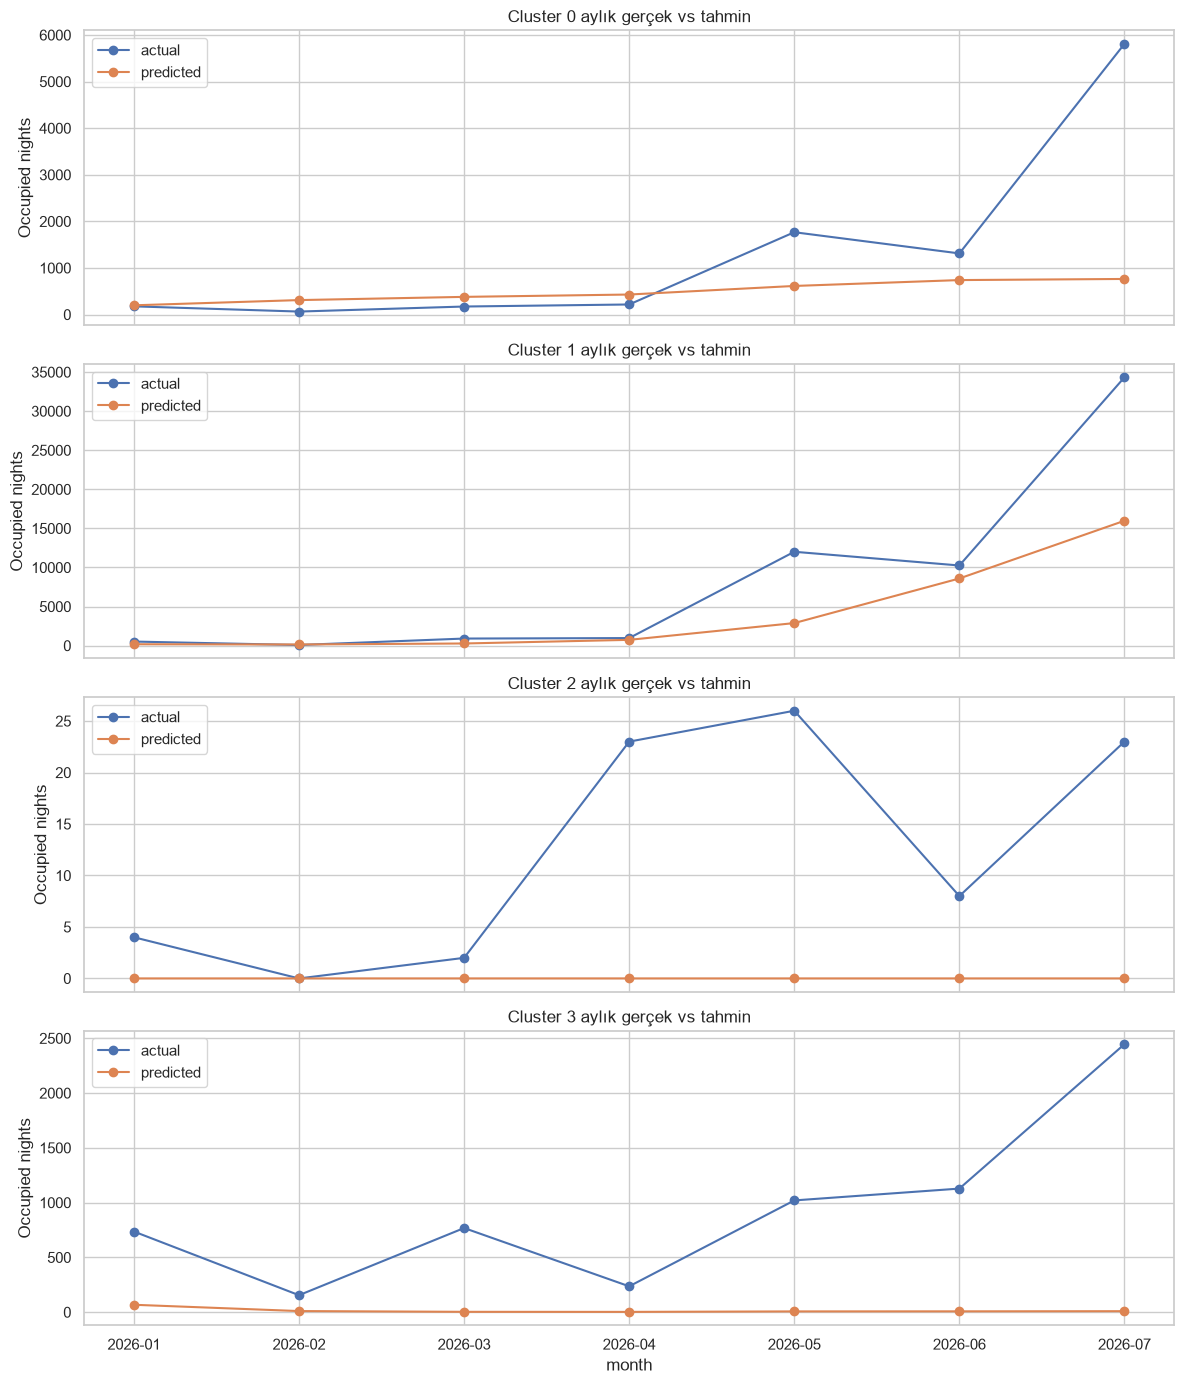

,cluster_id,otel_sayisi,secilen_model,MAE,WMAE,RMSE,MAPE,WMAPE,R2
0,0,737,GradientBoosting,0.075,5.810,0.610,94.440,123.871,-0.039
1,1,82,GradientBoosting,2.991,23.618,8.452,90.551,88.043,0.146
2,2,18,CatBoost,0.023,1.326,0.173,100.000,100.000,-0.017
3,3,30,CatBoost,1.018,11.655,3.435,99.192,99.820,-0.077


,hotel_id,hotel_name,cluster,model,actual_total,predicted_total,MAE,WMAE,RMSE,MAPE,WMAPE,R2
0,456,Robinson Çamyuva,1,GradientBoosting,3190.0,342.714,13.567,61.266,29.164,72.422,90.164,-0.098
1,181147,Belek Beach Resort Hotel,1,GradientBoosting,2936.0,338.985,12.276,41.065,22.785,81.452,88.642,-0.198
2,201949,Monachus Family Resort Sorgun,1,GradientBoosting,2656.0,342.706,10.952,48.057,23.491,74.288,87.420,-0.096
3,887,Sueno Hotels Deluxe Belek,1,GradientBoosting,2253.0,454.418,9.136,26.351,15.489,71.232,85.968,-0.106
4,813,Champion Holiday Village,1,GradientBoosting,2228.0,342.697,9.373,52.563,22.425,76.770,89.183,-0.007
5,471,Crystal Admiral Aqua Collection,1,GradientBoosting,1975.0,342.737,8.031,29.589,15.458,82.427,86.202,-0.023
6,1266,Swandor Hotels & Resort Topkapı Palace,3,CatBoost,1917.0,23.191,8.957,22.942,14.347,97.889,99.060,-0.617
7,646,Crystal Waterworld Aqua Collection,1,GradientBoosting,1897.0,349.633,7.473,34.511,16.671,72.753,83.520,-0.037
8,181836,La Benata Hotel,1,GradientBoosting,1890.0,342.603,7.705,44.739,19.093,71.844,86.429,-0.010
9,647,Crystal Sunset Pearl Collection,1,GradientBoosting,1868.0,342.690,7.224,25.754,13.844,75.829,81.987,0.005


,hotel_id,hotel_name,cluster,model,actual_total,predicted_total,MAE,WMAE,RMSE,MAPE,WMAPE,R2
0,9933,Paloma Finesse,1,GradientBoosting,408.0,341.628,1.085,3.457,2.166,66.369,56.394,0.544
1,3213,Club Marco Polo,1,GradientBoosting,561.0,341.594,1.501,6.647,3.503,40.121,56.722,0.471
2,168642,Rubi Platinum Sign,1,GradientBoosting,425.0,341.745,1.211,4.465,2.509,62.811,60.413,0.513
3,1400,Orange County Alanya,1,GradientBoosting,780.0,342.896,2.225,7.126,4.293,55.789,60.472,0.350
4,9621,Kirman Belazur Resort & Spa,1,GradientBoosting,368.0,341.914,1.080,3.817,2.291,67.313,62.202,0.506
5,3106,Leodikya Kirman Premium,1,GradientBoosting,363.0,341.603,1.066,3.872,2.116,54.322,62.246,0.595
6,886,Kimeros Park Holiday Village,1,GradientBoosting,815.0,341.748,2.473,9.988,5.251,52.202,64.331,0.347
7,698,Aydınbey Gold Dreams Hotel,1,GradientBoosting,319.0,342.542,0.974,3.650,2.188,77.363,64.755,0.418
8,468,Sueno Hotels Golf Belek,1,GradientBoosting,566.0,338.722,1.735,8.757,4.364,58.701,65.001,0.285
9,275208,Paloma Sencia,1,GradientBoosting,686.0,340.550,2.114,9.083,4.529,54.621,65.333,0.422


,Ay,Gercek,Tahmin,Fark,Yuzde_Hata
0,2026-01,1436.0,442.01,-993.99,69.22
1,2026-02,298.0,465.61,167.61,56.24
2,2026-03,1846.0,655.02,-1190.98,64.52
3,2026-04,1441.0,1170.23,-270.77,18.79
4,2026-05,14822.0,3503.81,-11318.19,76.36
5,2026-06,12702.0,9339.50,-3362.50,26.47
6,2026-07,42613.0,16750.55,-25862.45,60.69


In [7]:
def grouped_metrics(frame, group_columns):
    rows = []
    group_key = group_columns[0] if len(group_columns) == 1 else group_columns
    for keys, group in frame.groupby(group_key, dropna=False):
        keys = (keys,) if len(group_columns) == 1 else keys
        row = dict(zip(group_columns, keys))
        row.update(regression_metrics(group["occupied_nights"], group["prediction"]))
        rows.append(row)
    return pd.DataFrame(rows)

# Analiz 1: cluster performansı
cluster_metrics = grouped_metrics(test_results, ["cluster_id"])
cluster_model_performance = (
    cluster_summary[["cluster_id", "hotel_count"]]
    .merge(pd.DataFrame({"cluster_id": list(selected_models), "selected_model": list(selected_models.values())}), on="cluster_id")
    .merge(cluster_metrics, on="cluster_id")
    .rename(columns={"hotel_count": "otel_sayisi", "selected_model": "secilen_model"})
)
cluster_model_performance.to_csv(OUTPUT_DIR / "cluster_model_performance.csv", index=False, encoding="utf-8-sig")

# Otel metrikleri: Analiz 2 ve 3 ortak tabanı
hotel_metrics = grouped_metrics(test_results, ["hotel_id", "hotel_name", "cluster_id", "model"])
hotel_totals = (
    test_results.groupby(["hotel_id", "hotel_name", "cluster_id", "model"], as_index=False)
    .agg(actual_total=("occupied_nights", "sum"), predicted_total=("prediction", "sum"))
)
hotel_performance = hotel_totals.merge(
    hotel_metrics, on=["hotel_id", "hotel_name", "cluster_id", "model"], how="left"
).rename(columns={"cluster_id": "cluster"})

# Analiz 2: hacim top 20
top20_volume_hotels = hotel_performance.nlargest(20, "actual_total").reset_index(drop=True)
top20_volume_hotels.to_csv(OUTPUT_DIR / "top20_volume_hotels.csv", index=False, encoding="utf-8-sig")

top20_ids = top20_volume_hotels["hotel_id"]
top20_monthly = test_results.loc[test_results["hotel_id"].isin(top20_ids)].copy()
top20_monthly["month"] = top20_monthly["date"].dt.to_period("M").astype(str)
top20_monthly = top20_monthly.groupby(["hotel_id", "hotel_name", "month"], as_index=False).agg(
    actual=("occupied_nights", "sum"), predicted=("prediction", "sum")
)
fig, axes = plt.subplots(5, 4, figsize=(18, 20), sharex=True)
for ax, (hotel_id, group) in zip(axes.flat, top20_monthly.groupby("hotel_id", sort=False)):
    group.plot(x="month", y=["actual", "predicted"], marker="o", ax=ax)
    ax.set_title(str(group["hotel_name"].iloc[0])[:34], fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=7)
fig.suptitle("2026 Ocak-Temmuz: En yüksek hacimli 20 otel aylık gerçek vs tahmin", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "top20_volume_monthly_actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

# Analiz 3: WMAPE'ye göre en başarılı 20; gerçek hacmi sıfır olanlar sıralamaya alınmaz.
best_accuracy_hotels = (
    hotel_performance.loc[hotel_performance["actual_total"].gt(0) & hotel_performance["WMAPE"].notna()]
    .sort_values(["WMAPE", "MAE"])
    .head(20)
    .reset_index(drop=True)
)
best_accuracy_hotels.to_csv(OUTPUT_DIR / "best_accuracy_hotels.csv", index=False, encoding="utf-8-sig")

# Analiz 4: Antalya aylık toplamları
monthly_antalya_totals = test_results.assign(month=test_results["date"].dt.to_period("M").astype(str)).groupby("month", as_index=False).agg(
    Gercek=("occupied_nights", "sum"), Tahmin=("prediction", "sum")
).rename(columns={"month": "Ay"})
monthly_antalya_totals["Fark"] = monthly_antalya_totals["Tahmin"] - monthly_antalya_totals["Gercek"]
monthly_antalya_totals["Yuzde_Hata"] = np.where(
    monthly_antalya_totals["Gercek"].ne(0),
    monthly_antalya_totals["Fark"].abs() / monthly_antalya_totals["Gercek"] * 100,
    np.nan,
)
monthly_antalya_totals.to_csv(OUTPUT_DIR / "monthly_antalya_totals.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(11, 5))
monthly_antalya_totals.plot(x="Ay", y=["Gercek", "Tahmin"], marker="o", linewidth=2, ax=ax)
ax.set(title="Antalya aylık occupied nights: gerçek vs tahmin", ylabel="Occupied nights")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "monthly_antalya_actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=monthly_antalya_totals, x="Ay", y="Yuzde_Hata", color="#e76f51", ax=ax)
ax.set(title="Antalya aylık yüzde hata", ylabel="Mutlak yüzde hata (%)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "monthly_antalya_percentage_error.png", dpi=160, bbox_inches="tight")
plt.show()

cumulative = monthly_antalya_totals.copy()
cumulative["Kumulatif_Gercek"] = cumulative["Gercek"].cumsum()
cumulative["Kumulatif_Tahmin"] = cumulative["Tahmin"].cumsum()
fig, ax = plt.subplots(figsize=(11, 5))
cumulative.plot(x="Ay", y=["Kumulatif_Gercek", "Kumulatif_Tahmin"], marker="o", linewidth=2, ax=ax)
ax.set(title="Antalya kümülatif occupied nights", ylabel="Kümülatif occupied nights")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cumulative_antalya_actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

# Analiz 5: cluster aylık toplamları
monthly_cluster_totals = test_results.assign(month=test_results["date"].dt.to_period("M").astype(str)).groupby(
    ["cluster_id", "model", "month"], as_index=False
).agg(actual=("occupied_nights", "sum"), predicted=("prediction", "sum"))
monthly_cluster_totals["difference"] = monthly_cluster_totals["predicted"] - monthly_cluster_totals["actual"]
monthly_cluster_totals["percentage_error"] = np.where(
    monthly_cluster_totals["actual"].ne(0),
    monthly_cluster_totals["difference"].abs() / monthly_cluster_totals["actual"] * 100,
    np.nan,
)
monthly_cluster_totals.to_csv(OUTPUT_DIR / "monthly_cluster_totals.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(optimal_k, 1, figsize=(12, 3.5 * optimal_k), sharex=True)
axes = np.atleast_1d(axes)
for ax, (cluster_id, group) in zip(axes, monthly_cluster_totals.groupby("cluster_id")):
    group.plot(x="month", y=["actual", "predicted"], marker="o", ax=ax)
    ax.set_title(f"Cluster {cluster_id} aylık gerçek vs tahmin")
    ax.set_ylabel("Occupied nights")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "monthly_cluster_actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

display(cluster_model_performance.round(3))
display(top20_volume_hotels.round(3))
display(best_accuracy_hotels.round(3))
display(monthly_antalya_totals.round(2))

## 6. Özet rapor

Aşağıdaki hücre hesaplanan tabloları kullanarak `summary_report.md` dosyasını üretir. Bulgular test sonuçlarına dayanır; düşük performans olduğu gibi raporlanır.

In [10]:
def markdown_table(frame, float_digits=2):
    formatted = frame.copy()
    for column in formatted.select_dtypes(include="number").columns:
        formatted[column] = formatted[column].map(
            lambda value: "" if pd.isna(value) else f"{value:.{float_digits}f}"
        )
    headers = [str(column) for column in formatted.columns]
    rows = [[str(value).replace("|", "\\|") for value in row] for row in formatted.to_numpy()]
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines.extend("| " + " | ".join(row) + " |" for row in rows)
    return "\n".join(lines)


overall_metrics = regression_metrics(test_results["occupied_nights"], test_results["prediction"])
overall_actual = float(test_results["occupied_nights"].sum())
overall_predicted = float(test_results["prediction"].sum())
overall_bias_pct = (overall_predicted - overall_actual) / overall_actual * 100 if overall_actual else np.nan
best_month = monthly_antalya_totals.loc[monthly_antalya_totals["Yuzde_Hata"].idxmin()]
worst_month = monthly_antalya_totals.loc[monthly_antalya_totals["Yuzde_Hata"].idxmax()]

cluster_report = cluster_summary.merge(
    cluster_model_performance[["cluster_id", "secilen_model", "MAE", "WMAE", "RMSE", "MAPE", "WMAPE", "R2"]],
    on="cluster_id",
)
volume_report = top20_volume_hotels[["hotel_id", "hotel_name", "cluster", "model", "actual_total", "predicted_total", "WMAPE", "R2"]].head(10)
accuracy_report = best_accuracy_hotels[["hotel_id", "hotel_name", "cluster", "model", "MAE", "WMAPE", "R2"]].head(10)

report = f"""# Antalya Cluster Bazlı Talep Tahmini - Özet Rapor

## 1. Seçilen optimum cluster sayısı

`k=2..8` aralığında silhouette, Davies-Bouldin ve inertia dirsek gücünün normalize birleşik skoru kullanıldı. Seçilen optimum cluster sayısı **{optimal_k}** oldu. Merkezler, 2025 toplam occupied nights değeri en az {MIN_CLUSTER_SIGNAL} olan {int(fit_mask.sum())} otelde öğrenildi; düşük sinyalli oteller en yakın merkeze atandı.

{markdown_table(cluster_diagnostics.round(4), 4)}

## 2. Cluster özellikleri

{markdown_table(cluster_summary.round(3), 3)}

Cluster merkezlerinin tam 365 günlük eğrileri `cluster_centers.csv`, otel atamaları `hotel_cluster_assignments.csv` dosyasındadır.

## 3. Her cluster için en iyi model

2025 Ocak-Temmuz recursive validation WMAPE sonucuna göre seçim yapıldı.

{markdown_table(cluster_model_performance[["cluster_id", "otel_sayisi", "secilen_model"]], 0)}

## 4. Cluster bazlı hata metrikleri

{markdown_table(cluster_report[["cluster_id", "hotel_count", "secilen_model", "MAE", "WMAE", "RMSE", "MAPE", "WMAPE", "R2"]], 3)}

Tüm Antalya testinde MAE **{overall_metrics['MAE']:.3f}**, RMSE **{overall_metrics['RMSE']:.3f}**, WMAPE **{overall_metrics['WMAPE']:.2f}%** ve R² **{overall_metrics['R2']:.3f}** oldu.

## 5. En yüksek hacimli otellerin performansı

İlk 10 görünümü aşağıdadır; tam ilk 20 liste `top20_volume_hotels.csv` dosyasındadır.

{markdown_table(volume_report, 2)}

## 6. En başarılı otellerin performansı

WMAPE sıralamasında gerçek toplamı sıfır olan oteller dışarıda bırakıldı. İlk 10 görünümü aşağıdadır; tam ilk 20 liste `best_accuracy_hotels.csv` dosyasındadır.

{markdown_table(accuracy_report, 2)}

## 7. Antalya toplam aylık performansı

{markdown_table(monthly_antalya_totals, 2)}

Ocak-Temmuz gerçek toplamı **{overall_actual:,.0f}**, tahmin toplamı **{overall_predicted:,.0f}** occupied nights oldu. Toplam yanlılık **{overall_bias_pct:.2f}%**. En düşük aylık yüzde hata **{best_month['Ay']} ({best_month['Yuzde_Hata']:.2f}%)**, en yüksek hata **{worst_month['Ay']} ({worst_month['Yuzde_Hata']:.2f}%)** döneminde görüldü.

## 8. Güçlü ve zayıf yönler

**Güçlü yönler**

- Check-in dahil/check-out hariç gerçek inhouse hedefi ve kesintisiz otel-gün paneli kullanıldı.
- Cluster seçimi birden çok iç kalite metriğine, model seçimi ileri dönem recursive validation'a dayandırıldı.
- Cluster bazında farklı algoritma seçimine ve otel/cluster/Antalya seviyesinde izlenebilir çıktılara izin verildi.

**Zayıf yönler**

- 2026 yaz hacmi ciddi biçimde düşük tahmin edildi; toplam yanlılık {overall_bias_pct:.2f}% ve genel WMAPE {overall_metrics['WMAPE']:.2f}% seviyesinde.
- Cluster 0 çok sayıda düşük sinyalli otel içeriyor; sparse serilerde oran metrikleri ve recursive tahmin kararsızlaşabiliyor.
- İstenen feature setinde otel kimliği, kapasite, fiyat, pazar, rezervasyon eğrisi veya tatil/event bilgisi yok. Pooled cluster modeli aynı takvim/lag durumundaki otelleri ayırt edemiyor.
- Recursive yaklaşım uzun ufukta hatayı biriktiriyor. Validation sonuçlarındaki bazı ağaç modellerinin aşırı WMAPE değerleri bu riski gösteriyor.

## 9. Gelecek sezon kullanım önerileri

1. Bu sürümü doğrudan operasyonel bütçe tahmini olarak kullanmayın; özellikle Mayıs-Temmuz için kalibrasyon ve insan kontrolü uygulayın.
2. Otel kapasitesi ve otel kimliği/embedding, fiyat, bölge, konsept, pazar ve resmi tatil-event feature'larını ekleyin.
3. Düşük hacimli otelleri ayrı bir zero-inflated veya occurrence-plus-volume modeliyle ele alın; minimum geçmiş/hacim eşiği tanımlayın.
4. Tek seferlik 7 aylık recursive tahmin yerine haftalık/aylık yeniden tahmin ve expanding-window backtest kullanın.
5. Model seçimini yalnız WMAPE değil WMAPE, bias ve R² birlikte izleyen iş kuralıyla yapın; yaz aylarına daha yüksek ağırlık verin.
6. 2026 verisinin henüz tamamlanmamış veya booking cut-off etkisi taşıyıp taşımadığını doğrulayın; kaynak kapsamı eksikse hata modelden değil veri olgunluğundan kaynaklanabilir.
"""

report_path = OUTPUT_DIR / "summary_report.md"
report_path.write_text(report, encoding="utf-8")

run_manifest = {
    "generated_at": pd.Timestamp.now().isoformat(),
    "data_path": str(DATA_PATH),
    "output_dir": str(OUTPUT_DIR),
    "train_period": [str(TRAIN_START.date()), str(TRAIN_END.date())],
    "test_period": [str(TEST_START.date()), str(TEST_END.date())],
    "optimal_k": optimal_k,
    "selected_models": {str(int(key)): value for key, value in selected_models.items()},
    "overall_metrics": overall_metrics,
}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Rapor oluşturuldu: {report_path}")
print(f"Toplam gerçek={overall_actual:,.0f}, tahmin={overall_predicted:,.0f}, WMAPE={overall_metrics['WMAPE']:.2f}%")

Rapor oluşturuldu: c:\Users\efe.turhan\Desktop\sales_forecasting\output1\summary_report.md
Toplam gerçek=75,158, tahmin=32,327, WMAPE=93.61%
